# Bayesian Optimization Demo

**Summary**: This is a simple demo code that can serve as a precursor to understanding the Bayesian optimization approach employed by bayesopt.py. All the code is implemented here in this document for maximum transparency.

## Motivation

Say we have a model and we have some data. We want to find the best parameters of the model to fit the data. Some properties of this model are:

- it's complicated; we have many paramters to search over
- there is some stochasticity in the outputs and/or the paramters are not differentiable relative to the outputs at all points
- there is not closed form solution to fit the model to the data

We'll need to rely on iterative/numerical methods for optimizing this model. 

Typically, you would use gradient descent, which is highly scalable and efficient. But this requires that you can compute the gradient of the variables with respect to the cost function (the function used to to evaluate how well the model outputs approximate the data). In the hypothetical model we are considering, it is unclear or difficult to derive the gradients. Perhaps it has some inherent stochasticisty or the outputs are not differentiable at all points with respect to the parameters.

In this case, you may want to look for other methods to optimize your model. You can use grid search, which exhaustively searches over a slice of paramter space by incrementing each paramter sequentially. This is the most computationally costly method and isn't practical if your model has a lot of parameters.

You could use random search. Rather than exhaustively compute every paramter combination, you will sample some paramters from a set of possibilities and evaluate the model at each point. This covers more ground in paramter space, but you might sacrifice the quality of fit since you are not guaranteed to get the optimal solution for finite samples (although you will in the infinite-sample limit).

You can refine the random search method by only checking spots where you expect to get a lower cost. This is where the class of Bayesian Optimization methods comes in handy. In the method demonstrated in this notebook, we implement a method that searches randomly in model parameter space for solutions, but does so in a manner informed by experience with previous parameter selections. During this process, as we accumulate new samples and compute their loss, we maintain a posterior probability distribution over the parameters. This posterior distribution estimates the probability of the cost at any given point in paramter space. We can then draw from this posterior distribution iteratively. Each successive draw gives us a new model with a new cost. This updates our posterior distribution, and we continue on drawing until we are satisfied with the quality of fit. This approach converges to the optimal solution much more quickly than plain random search.

This is precursor to understanding the approach taken by [Wu et al. (2023)](https://pmc.ncbi.nlm.nih.gov/articles/PMC10542160/). In this model, we'll walk through an example where we fit a simple model to some simulated data.

## Process

In plain language, the algorithm is a kind of expedited random search where the search points are prioritized according to an explicit model of the cost landscape. Here is how it works:

1) Randomly select a number of parameter sets for the model over some prior distribution.
2) Compute the cost function between the model outputs and the target data.
3) Fit a Gaussian process to the cost samples to model the cost landscape.
4) Define an acquisition function (we use expected improvement) that balances two goals, minimize the cost (exploit) and increase information about the cost function (explore). We also add in an additional requirement that the parameters have to be feasible. Take the max of this acquisition function to get a new parameterization.
5) Repeat 2-4 some finite number of times and take the one with the min cost

## Algorithm

**Algorithm**:

**Input**:  
- Search region $\Theta$  
- Maximum number of iterations K
- R number of simulations to run

---

**Initialization**  
1. Sample 5 initial parameter sets, either uniformly at random or according to a prior distribution. Let this set be $\hat{\theta}$ (theta-hat).  
2. For each $\theta \in \hat{\theta}$:
   - Let each simulation cost be $\hat{c}(\theta)_r, r = 1..R$.  
   - Define the estimated cost:  
       $\hat{c}(\theta) = \frac{1}{R}\sum_{r=1}^{R} \hat{c}(\theta)_r$
3. Define $\hat{C} = { \hat{c}(\theta) : \theta \in \hat{\theta}}$.

---

**Main Loop**  
For k = 1..K:
1. Fit a Gaussian Process (GP) to ($\hat{\theta}$, $\hat{C}$).  
2. For all $\theta \in \Theta$, compute the acquisition function $a(\theta)$ (e.g., Expected Improvement).  
3. Pick $\theta_k = \arg\max a(\theta)$.  
4. Run R simulations for $\theta_k$ to get $\hat{c}(\theta_k)_r, r = 1..R$.  
5. Average them:  
     $\hat{c}(\theta_k) = \frac{1}{R}\sum_{r=1}^{R} \hat{c}(\theta_k)_r$
6. Update $\hat{\theta} \leftarrow \hat{\theta} \cup {\theta_k}$ and $\hat{C} \leftarrow \hat{C} \cup {\hat{c}(\theta_k)}$.

---

**Return**  
  $\theta^* = \arg\min_{\theta \in \hat{\theta}} \hat{c}(\theta).$

## Set Main Directory

In [4]:
mainDir = '.'
SSNDir = '../' #path to directory with SSN code

## Add Paths

In [5]:
import sys
sys.path.insert(1, mainDir)
sys.path.append(SSNDir)

## Imports

In [6]:
import numpy as np
import json
import pandas as pd
import os
from ssn_v1 import SSN_utils
from ssn_v1 import SSN
from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline
import h5py
import paramiko
import matplotlib.pyplot as plt
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
import h5py
import errno
import paramiko
import tempfile

In [7]:
# Check pwd
os.system('pwd')

/Users/Joe/Documents/GitHub/ssn-v1/bayesopt_demo


0

## Bayesian Optimization

The next bit will do the following:

1) create a process for generating data
2) create a model for those data
3) establish a bayesian optimization process for fitting those data

In [8]:
"""
Debugging Model For Bayesian Optimization

This file now demonstrates how to:
1) Generate a ground-truth dataset of (Nconditions x Nneurons) integer firing rates
   from a lognormal distribution parameterized by alpha_true, beta_true.
2) For each candidate (alpha, beta), simulate multiple random instantiations (like
   repeated random seeds) of the same shape, fit lognormal distributions for each condition,
   and compute the sum of KL divergences relative to the ground-truth distributions.
3) Use Bayesian Optimization (GP + Expected Improvement) to find alpha, beta.
"""

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

########################################
# 1) Utility: Generating Ground Truth Data
########################################

def generate_ground_truth_data(alpha_true, beta_true, x_values, Nneurons=100, sigma_gt=0.4, seed=123):
    """
    Generate a ground-truth dataset of shape (Ncond x Nneurons), each entry is an integer
    firing rate drawn from a lognormal distribution. The real-space mean for condition i is:
      mean_i = alpha_true * x_i + beta_true * sqrt(x_i)
    We'll interpret sigma_gt as the log-space std dev.

    Returns
    -------
    ground_truth_data : np.ndarray, shape (Ncond, Nneurons)
        Each row is one condition, each column is one "neuron".
    """
    rng = np.random.default_rng(seed)
    Ncond = len(x_values)
    ground_truth_data = np.zeros((Ncond, Nneurons), dtype=int)

    for i, x in enumerate(x_values):
        mean_real = alpha_true * x + beta_true * np.sqrt(x)
        if mean_real <= 0:
            mean_real = 1e-9
        loc = np.log(mean_real) - 0.5*(sigma_gt**2)  # log-space mean
        scale = sigma_gt
        samples = rng.lognormal(mean=loc, sigma=scale, size=Nneurons)
        ground_truth_data[i, :] = np.round(samples).astype(int)

    return ground_truth_data

########################################
# 2) Model Simulation for a Candidate (alpha, beta)
########################################

def simulate_model_data(alpha, beta, x_values, Nneurons=100, sigma_model=0.4, seed=None):
    """
    Given alpha, beta, generate data shaped (Ncond x Nneurons) for each condition x_i.
    The real-space mean is alpha*x + beta*sqrt(x). Then we sample from a lognormal.
    """
    rng = np.random.default_rng(seed)
    Ncond = len(x_values)
    model_data = np.zeros((Ncond, Nneurons), dtype=int)

    for i, x in enumerate(x_values):
        mean_real = alpha * x + beta * np.sqrt(x)
        if mean_real <= 0:
            mean_real = 1e-9
        loc = np.log(mean_real) - 0.5*(sigma_model**2)
        scale = sigma_model
        samples = rng.lognormal(mean=loc, sigma=scale, size=Nneurons)
        model_data[i, :] = np.round(samples).astype(int)

    return model_data

########################################
# 3) KL Divergence Helpers
########################################

def kl_divergence_lognormal(mu1, s1, mu2, s2):
    """
    Closed-form KL divergence D_KL( LN(mu1, s1^2) || LN(mu2, s2^2) ).
    mu1, mu2: means of underlying Normal
    s1, s2 : std dev of underlying Normal
    """
    return np.log(s2 / s1) + (s1**2 + (mu1 - mu2)**2) / (2 * s2**2) - 0.5


def estimate_lognormal_params(data):
    """
    Given an array of shape (Nneurons) of integer firing rates (>=0),
    estimate the lognormal distribution parameters in log-space.

    Returns
    -------
    mu_est, sigma_est : float
        The sample mean and sample std of log(data).
    """
    safe_data = np.clip(data.astype(float), 1e-9, None)
    logvals = np.log(safe_data)
    mu_est = np.mean(logvals)
    var_est = np.var(logvals, ddof=1)
    sigma_est = np.sqrt(var_est)
    return mu_est, sigma_est


def loss_across_conditions(ground_truth_data, model_data):
    """
    Compare the distributions in ground_truth_data vs. model_data across conditions.
    For each condition i, we fit LN(mu_gt, sigma_gt) to ground_truth_data[i, :]
    and LN(mu_m, sigma_m) to model_data[i, :]. Then compute sum of KL.

    The shape of both inputs is (Ncond, Nneurons).
    """
    Ncond = ground_truth_data.shape[0]
    total_kl = 0.0
    for i in range(Ncond):
        gt_mu, gt_sigma = estimate_lognormal_params(ground_truth_data[i, :])
        m_mu, m_sigma    = estimate_lognormal_params(model_data[i, :])
        kl_val = kl_divergence_lognormal(gt_mu, gt_sigma, m_mu, m_sigma)
        total_kl += kl_val
    return total_kl

########################################
# 4) Evaluate Parameters with Multiple Instances
########################################

def evaluate_parameters_debug(
    theta,
    x_values,
    ground_truth_data,
    sigma_model=0.4,
    n_inst=5,
    seed=None
):
    """
    For a guess (alpha, beta) = theta,
    1) simulate model_data n_inst times
    2) compute the KL-based loss vs ground_truth_data
    3) return the average across n_inst instantiations.
    """
    alpha, beta = theta
    rng = np.random.default_rng(seed)

    accum_kl = 0.0
    for _ in range(n_inst):
        # random seed for each inst
        subseed = rng.integers(0, 10_000)
        model_data = simulate_model_data(alpha, beta, x_values,
                                         Nneurons=ground_truth_data.shape[1],
                                         sigma_model=sigma_model,
                                         seed=subseed)
        kl_val = loss_across_conditions(ground_truth_data, model_data)
        accum_kl += kl_val

    return accum_kl / n_inst

########################################
# 5) Bayesian Optimization with scikit-learn GP
########################################

def expected_improvement(mu, sigma, best_loss):
    """
    Standard EI formula for Bayesian Optimization.
    best_loss is the best (lowest) loss so far.
    Z = (best_loss - mu)/sigma
    EI = (best_loss - mu)*Phi(Z) + sigma*phi(Z) if improvement>0 else 0
    """
    eps = 1e-12
    Z = (best_loss - mu) / (sigma + eps)

    from scipy.stats import norm
    phi = norm.pdf(Z)
    Phi = norm.cdf(Z)

    improvement = best_loss - mu
    ei = improvement * Phi + sigma * phi
    ei[improvement < 0] = 0.0
    return ei


def simple_bayesopt_demo(
    x_values,
    ground_truth_data,
    n_init=5,
    max_iter=20,
    param_bounds=((0.0, 5.0), (0.0, 3.0)),
    sigma_model=0.4,
    n_inst=5,
    random_state=42
):
    """
    A demonstration of Bayesian Optimization searching for (alpha, beta)
    to match the ground_truth_data (Ncond x Nneurons) that was generated.

    We do:
      - sample random param sets
      - compute cost via evaluate_parameters_debug
      - fit GP
      - pick next param set by EI
      - repeat
    """
    rng = np.random.default_rng(random_state)
    param_bounds = np.array(param_bounds)

    X_samples = []
    y_samples = []

    # 1) Initialization
    for _ in range(n_init):
        alpha = rng.uniform(param_bounds[0,0], param_bounds[0,1])
        beta  = rng.uniform(param_bounds[1,0], param_bounds[1,1])
        theta = np.array([alpha, beta])

        cost_val = evaluate_parameters_debug(
            theta,
            x_values,
            ground_truth_data,
            sigma_model=sigma_model,
            n_inst=n_inst,
            seed=rng.integers(0, 10_000)
        )
        X_samples.append(theta)
        y_samples.append(cost_val)

    X_samples = np.array(X_samples)
    y_samples = np.array(y_samples)

    kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e2))
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=0.0,
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=random_state
    )

    min_loss_history = []

    # 2) Main BO loop
    for iteration in range(max_iter):
        # fit GP on existing data
        gp.fit(X_samples, y_samples)
        
        plot_gp_for_parameter(
            X_samples,
            y_samples,
            gp,
            param_bounds,
            param_index=[0,1]
        )

        best_loss = np.min(y_samples)
        min_loss_history.append(best_loss)

        # propose new param by sampling
        n_candidates = 1000
        c_alphas = rng.uniform(param_bounds[0,0], param_bounds[0,1], n_candidates)
        c_betas  = rng.uniform(param_bounds[1,0], param_bounds[1,1], n_candidates)
        candidate_thetas = np.vstack((c_alphas, c_betas)).T

        mu_pred, sigma_pred = gp.predict(candidate_thetas, return_std=True)
        ei_values = expected_improvement(mu_pred, sigma_pred, best_loss)
        best_idx = np.argmax(ei_values)
        new_theta = candidate_thetas[best_idx]

        # evaluate
        cost_val = evaluate_parameters_debug(
            new_theta,
            x_values,
            ground_truth_data,
            sigma_model=sigma_model,
            n_inst=n_inst,
            seed=rng.integers(0,10_000)
        )

        # update
        X_samples = np.vstack((X_samples, new_theta))
        y_samples = np.append(y_samples, cost_val)

        print(f"Iteration {iteration+1}/{max_iter}: new loss={cost_val:.4f}, best so far={best_loss:.4f}")

    overall_best_idx = np.argmin(y_samples)
    best_params = X_samples[overall_best_idx]
    best_loss_value = y_samples[overall_best_idx]

    print("\nFinal:")
    print(f"  best_params={best_params}")
    print(f"  best_loss={best_loss_value:.6f}")

    return best_params, best_loss_value, min_loss_history, gp, X_samples, y_samples

########################################
# Visualize
########################################
def plot_gp_heatmaps_2d_with_samples(
    gp,
    param_bounds,
    X_samples,
    y_samples,
    n_points=50,
    title="GP"
):
    """
    Plot side-by-side heatmaps of the GP-predicted mean and std for a 2D (alpha,beta) model,
    and overlay the sampled points (X_samples).

    Parameters
    ----------
    gp : GaussianProcessRegressor
        The fitted GP model.
    param_bounds : list of (float, float)
        Bounds for the two parameters, e.g. [(alpha_min, alpha_max), (beta_min, beta_max)].
    X_samples : np.ndarray
        Shape [n_samples, 2] with [alpha, beta] for each sample.
    y_samples : np.ndarray
        Shape [n_samples,] with the observed losses for each sample (used only to color or label).
        If you just want to see the points, you can ignore y_samples or pass None and adapt.
    n_points : int, optional
        Number of points per dimension in the grid for plotting.
    """

    # Ensure we have exactly 2D param space
    if len(param_bounds) != 2:
        raise ValueError("plot_gp_heatmaps_2d_with_samples only supports 2 parameters (2D).")
    if X_samples.shape[1] != 2:
        raise ValueError("X_samples must have shape [n_samples, 2].")

    (alpha_min, alpha_max), (beta_min, beta_max) = param_bounds

    # Build a meshgrid of alpha, beta
    alpha_space = np.linspace(alpha_min, alpha_max, n_points)
    beta_space  = np.linspace(beta_min, beta_max, n_points)
    A, B = np.meshgrid(alpha_space, beta_space)  # shape: (n_points, n_points)

    # Flatten the grid and predict
    test_points = np.column_stack((A.ravel(), B.ravel()))  # shape (n_points^2, 2)
    mu_pred, sigma_pred = gp.predict(test_points, return_std=True)

    # Reshape into 2D for plotting
    M = mu_pred.reshape(n_points, n_points)
    S = sigma_pred.reshape(n_points, n_points)

    # Create side-by-side subplots
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True)

    # Left: predicted mean
    mean_ax = axes[0]
    c0 = mean_ax.imshow(
        M, 
        origin='lower', 
        extent=[alpha_min, alpha_max, beta_min, beta_max],
        aspect='auto', 
        cmap='viridis'
    )
    mean_ax.set_title(f"{title} Mean (Loss)")
    mean_ax.set_xlabel("Alpha")
    mean_ax.set_ylabel("Beta")
    fig.colorbar(c0, ax=mean_ax, label="Mean")

    # Overlay the sampled points on mean subplot
    # alpha => X_samples[:,0], beta => X_samples[:,1]
    mean_ax.scatter(X_samples[:,0], X_samples[:,1],
                    c='white', edgecolor='black', s=40,
                    label='Sampled points')
    mean_ax.legend()

    # Right: predicted std
    std_ax = axes[1]
    c1 = std_ax.imshow(
        S,
        origin='lower',
        extent=[alpha_min, alpha_max, beta_min, beta_max],
        aspect='auto',
        cmap='plasma'
    )
    std_ax.set_title(f"{title} Std Dev")
    std_ax.set_xlabel("Alpha")
    fig.colorbar(c1, ax=std_ax, label="Std")

    # Also overlay sampled points on std subplot (optional)
    std_ax.scatter(X_samples[:,0], X_samples[:,1],
                   c='white', edgecolor='black', s=40)

    plt.tight_layout()
    plt.show()
    
    return fig, mean_ax, std_ax

def plot_gp_for_parameter(
    X_samples, 
    y_samples, 
    gp, 
    param_bounds, 
    param_index=0,  # can be int or list/tuple/array of ints
    fixed_params=None, 
    n_points=200
):
    """
    Plot one or more 1D slices of the Gaussian Process for selected parameter dimensions.
    
    Parameters
    ----------
    X_samples : np.ndarray
        Shape [n_samples, n_params]. The parameter sets that have been sampled.
    y_samples : np.ndarray
        Shape [n_samples,]. The associated losses for each sampled parameter set.
    gp : GaussianProcessRegressor
        The fitted GP model.
    param_bounds : list of (float, float)
        The lower and upper bounds for each free parameter, as used in the optimization.
    param_index : int or list/tuple of int, optional
        The index (or indices) of the parameter dimension(s) to visualize.
        If multiple, each dimension gets its own subplot.
    fixed_params : np.ndarray or None, optional
        If None, we default to the best parameters from the optimization. Otherwise,
        you can pass in an array of shape [n_params] specifying how to fix
        the other parameter dimensions.
    n_points : int, optional
        Number of points in the grid for plotting.
    """
    X_samples = np.array(X_samples)
    y_samples = np.array(y_samples)
    n_samples, n_params = X_samples.shape

    # Handle param_index input (could be int or array-like)
    if isinstance(param_index, int):
        param_index = [param_index]
    elif isinstance(param_index, (list, tuple, np.ndarray)):
        param_index = list(param_index)  # ensure we can iterate
    else:
        raise ValueError("param_index must be int or array-like of ints.")

    # Validate each dimension
    for dim in param_index:
        if not (0 <= dim < n_params):
            raise ValueError(f"Invalid param_index {dim}, must be in [0, {n_params - 1}]")

    # If no fixed_params specified, pick the best from the samples
    if fixed_params is None:
        best_idx = np.argmin(y_samples)
        fixed_params = X_samples[best_idx].copy()
    else:
        fixed_params = np.array(fixed_params).copy()
        if fixed_params.shape[0] != n_params:
            raise ValueError(f"fixed_params must have length {n_params}")

    # Create subplots: one per requested dimension
    fig, axes = plt.subplots(
        1, len(param_index), 
        figsize=(5 * len(param_index), 4), 
        squeeze=False
    )
    axes = axes.flatten()  # so we can index easily

    for ax_i, dim in enumerate(param_index):
        # Build a grid for the chosen dimension
        lb, ub = param_bounds[dim]
        X_grid_1d = np.linspace(lb, ub, n_points)

        # Build test array
        X_test = []
        for val in X_grid_1d:
            test_params = fixed_params.copy()
            test_params[dim] = val
            X_test.append(test_params)
        X_test = np.array(X_test)

        # Predict with the GP
        mu_pred, sigma_pred = gp.predict(X_test, return_std=True)

        ax = axes[ax_i]
        ax.plot(X_grid_1d, mu_pred, label='GP mean prediction')
        ax.fill_between(
            X_grid_1d,
            mu_pred - 2.0 * sigma_pred,
            mu_pred + 2.0 * sigma_pred,
            alpha=0.2,
            label='GP ± 2 std'
        )
        # Overlay the actual sampled points along this dimension
        ax.scatter(X_samples[:, dim], y_samples,
                   marker='x', color='black', label='Sampled points')

        ax.set_xlabel(f'Parameter {dim}')
        ax.set_ylabel('Loss')
        ax.set_title(f'1D GP Slice for Param {dim}')
        ax.legend()

    plt.tight_layout()
    plt.show()

### Example Data

Let's first generate some data. The data will be generated according to a positive-valued distribution. We first define some relationship between the inputs $x$ and the mean of the distribution $\hat{r}$:

\begin{equation}
\hat{r} = \alpha_{true} x + \beta_{true} \sqrt{x}
\end{equation}

The mean $\hat{r}$ depends on two parameters, $\alpha_{true}$, which controls the linear component, and $\beta_{true}$, which controls the nonlinear component. $x$ is defined to be strictly positive. Then we generate the data by defining some distribution about this mean based on a log-normal distribution:

\begin{equation}
r \sim \text{Lognormal} (\hat{r},\sigma^2)
\end{equation}
\begin{equation}
\ln(r) \sim \mathcal{N}(\hat{r},\sigma^2)
\end{equation}

To generate the data, we'll just draw some samples from this distribution. This should roughly approximate the firing distribution of neurons.

The model will be of the same form of the data generating process:

\begin{equation}
\hat{r}_{model} = \alpha x + \beta \sqrt{x}
\end{equation}

where $\alpha$ and $\beta$ are estimates of the true parameter values. Like in the actual data, the firing rates in the model are randomly drawn from the distribution $y$.

Below, we generate firing rate distributions for four different $x$ conditions. The orange shows the underlying distribution that produced the data and the blue histogram shows the distribution of the sample for each condition.

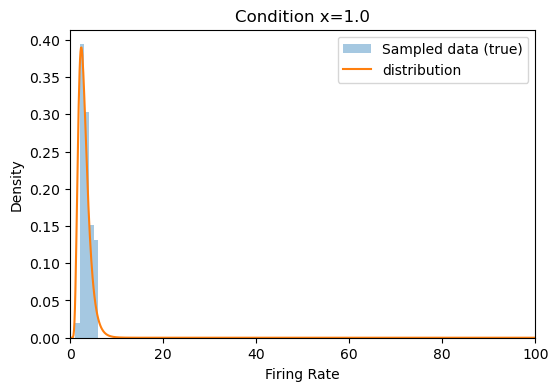

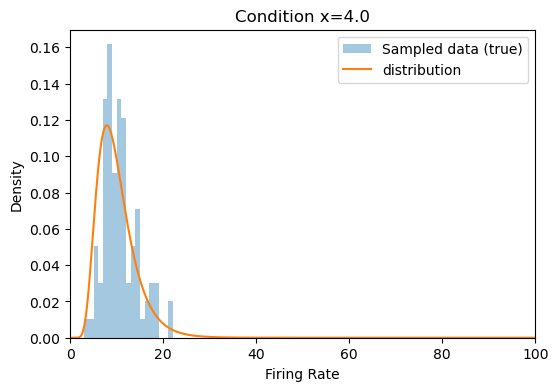

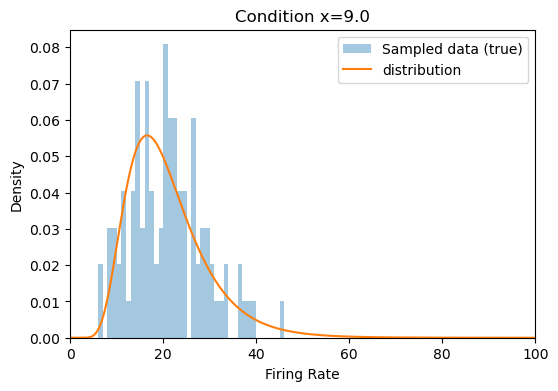

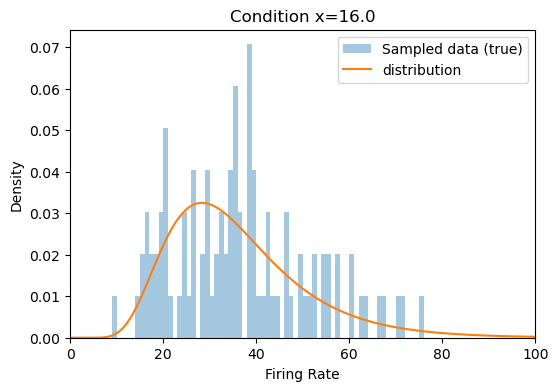

In [11]:
from scipy.stats import lognorm

########################################
# 4 conditions
Ncond = 4
x_values = np.array([1.0, 4.0, 9.0, 16.0])
# generate ground truth
alpha_true = 2.0 # true alpha param
beta_true  = 1.0 # true beta param
sigma_gt   = 0.4 # sigma param (we'll match this in the model for simplicity)
param_bounds=((0.0,5.0),(0.0,3.0)) # bounds for paramters (we'll restrict the search)
ground_truth_data = generate_ground_truth_data(
    alpha_true, beta_true, x_values,
    Nneurons=100,
    sigma_gt=sigma_gt,
    seed=123
)

# Generating distribution
def lognormal_pdf(alpha, beta, sigma, x_cond, r_range):
        mean_real = alpha*x_cond + beta*np.sqrt(x_cond)
        if mean_real <= 0:
            mean_real = 1e-9  # clamp to positive
        mu = np.log(mean_real) - 0.5*(sigma**2)
        # shape parameter = sigma, scale = exp(mu)
        return lognorm.pdf(r_range, s=sigma, scale=np.exp(mu))
distributions = []
r_range = np.linspace(0,100,1000)
for i, x in enumerate(x_values):
    d = lognormal_pdf(alpha_true, beta_true, sigma_gt, x, r_range)
    distributions.append(d)

# Make plots directory
if not os.path.exists(os.path.join(mainDir,"plots")):
    os.makedirs(os.path.join(mainDir,"plots"))

for i in range(Ncond):

    ground_truth_samples=ground_truth_data[i]
    bin_size=1
    x_condition=x_values[i]
    
    fig, ax = plt.subplots(figsize=(6,4))
    ax.hist(ground_truth_samples, bins=np.arange(0,np.max(ground_truth_samples),bin_size), density=True, alpha=0.4, label='Sampled data (true)')
    ax.plot(r_range,distributions[i],label='distribution')
    ax.set_xlabel('Firing Rate')
    ax.set_xlim([0,100])
    ax.set_ylabel('Density')
    ax.set_title(f'Condition x={x_condition}')
    ax.legend()
    plt.show()
    
    fig.savefig(os.path.join(mainDir,"plots",f"demo_GTdata_x={x_values[i]}.png"))

### Run Bayesian Optimization

Now let's look what happens when we deploy the Bayesian optimization method.

First we'll set some hyperparameters:
- n_init = 5; the number of parameter sets to randomly sample initially
- n_inst = 5; the number of model instances, since the model is stochastic, we want to reduce the noise in each measurement by sampling several times
- max_iter = 20; the total number of iterations

**Cost Function**

The cost function is how we'll evaluate the model fit to data. We're working with positive-valued distributions, and we want the model generated-distributions to match the data distributions. One metric for comparing the similarity of distributions is the **[Kullback-Leibler divergence](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence)**. It computes the excess suprisal of observing one distribution (P) given you are expecting the other distribution (Q) instead of the former (P). It is written as:

\begin{equation}
D_{KL}(P || Q) = \sum_{x \in \mathcal{X}} P(x)\text{log}\frac{P(x)}{Q(x)}
\end{equation}

It is also called **relative entropy** because it quantifies the amount of entropy (or information) that needs to be added to one distribution to make it equivalent to another. Shannon entropy is defined:

\begin{equation}
H(P) = -\sum_{x \in \mathcal{X}} P(x)\text{log}P(x)
\end{equation}

which quantifies the disorder of a system. In information theory, this quantifies the minimum amount of information needed to encode the system. More disordered states need more information (more bits) to encode. 

The [cross-entropy](https://en.wikipedia.org/wiki/Cross-entropy) is another concept from information theory that quantifies how many bits of information needs to encode one distribution (P) given the optimal code for another distribution (Q). This is given by:

\begin{equation}
H(P,Q) = -\sum_{x \in \mathcal{X}} P(x)\text{log}Q(x)
\end{equation}

The relative entropy is then the difference between the cross entropy and the entropy which quantifies the extra information needed to encode P using the optimal code for Q:

\begin{equation}
D_{KL}(P || Q) = H(P,Q) - H(P) = -\sum_{x \in \mathcal{X}} P(x)\text{log}Q(x) + \sum_{x \in \mathcal{X}} P(x)\text{log}P(x) = -\sum_{x \in \mathcal{X}} P(x)\text{log}\frac{P(x)}{Q(x)}
\end{equation}

**Gaussian Process**

To keep track of our posterior distribution, we'll use a model called a **Gaussian Process** (GP). To learn more about GPs, Joe recommends [this introduction](https://distill.pub/2019/visual-exploration-gaussian-processes/). But in the simplest terms possible, a GP estimates a probability distribution over a set of functions that fit some data. For each point in parameter space, the GP estimates a mean and variance. In our case, the GP will estimate the expected cost at a given parameterization and the uncertainty around that estimate. The uncertainty is determine by assumptions in how the loss will vary across parameterizations. One assumption you can make is that nearby points in parameter space will have similar losses. We can put these assumptions into a covariance kernel which will determine how the GP estimates will vary over parameter space.

Here's a rough summary on how GPs work:

1) GPs are **stochasic processes**: collections of random variables in probability space. For any finite collection of random variables, the GP descibes a multivariate normal distribution across these variables.

2) The random variables we choose for the GP are called **test points**. In our case, these test points will be possible parameterizations for the model. For any N samples in parameter space, we end up with a N-dimensional loss vector. The Gaussian process defines a **multivariate Gaussian distribution** over this N-dimensional space.

3) To determine how the covariance of the multivariate Gaussian distribution, a **kernel function** is employed. The kernel function determines how much different variables will covary with one another, or in other words, how much variables influence the values of other variables. This is where we bake in some assumptions about how we expect the function to vary across variables (parameter space). The **RBF kernel**, determines the covariance based on the relative distance between test points:

\begin{equation}
k_{RBF}(x,x') = \sigma^2 \exp\left(\frac{\left\|x-x'\right\|^2}{2l^2}\right)
\end{equation}

This kind of kernel is invariant to translations. In our case, it basically encodes the rule that similar locations in parameter space will have similar values. As you can see, it depends on two parameters: $\sigma$ which controls the variance determines the amount of deviation from the mean at any given point and $l$ (the length constant) determines how far away variables have to be from each other to exert influence. A smaller length constant means that variables are less dependent on each other at long distances and so it allows higher-frequency deviaitons. A larger length scale means that variables are more dependent on each other at long distances and so it yields lower-frequency deviations.

For this example we use a related kernel called the **Matern 5/2 kernel**. Like the RBF kernel, is it is translation invariant and assumes that nearby parameters have higher covariance. But unlike the RBF kernel, its good at accomodating non-smooth regions.

\begin{equation}
k_{Matern}(x,x') = \sigma^2 \frac{2^{1-\nu}}{\Gamma{\nu}}\left(\sqrt{2\nu}\frac{\left\|x-x'\right\|}{\rho}\right)^\nu K_{\nu}\left(\sqrt{2\nu}\frac{\left\|x-x'\right\|}{\rho}\right)
\end{equation}

where again $\sigma$ is the variance, $\rho$ is the length scale, and $\nu$ is the smoothness variable. Higher values of $\nu$ lead to greater smoothness. As $\nu \rightarrow \infty$, the Matern kernel becomes equivalent to the RBF kernel. The Matern 5/2 kernel uses $\nu=5/2$.

Choosing kernel parameters can be its own optimization process. For now, we'll choose the kernel parameters on each iteration by optimizing them to the [log-marginal-likelihood](https://en.wikipedia.org/wiki/Marginal_likelihood) (LML) using the [L-BFGS](https://link.springer.com/article/10.1007/BF01589116) gradient-based optimization method. The LML balances between model fit and model complexity and is asymptoticall equivalent to the [Bayesian Information Criterion](https://en.wikipedia.org/wiki/Bayesian_information_criterion) (BIC) ([Schwartz, 1978](https://projecteuclid.org/journals/annals-of-statistics/volume-6/issue-2/Estimating-the-Dimension-of-a-Model/10.1214/aos/1176344136.full)).

4) GPs start off with a **prior distribution**. This usually is assumed to have a mean of zero everywhere.

5) Once we observe some data, we add these to the Gaussian process by **conditioning** the multivariate distribution on these observations. More intuitively, we restrict the set of possible functions to those that pass through the observed data (or we can put a less stringest constraint by assuming some sampling noise in the data). For each of the random variables, we can get the mean and variance of the function value at that point by **marginalizing** the multivariate Gaussian distribution. By fixing (or otherwise restraining) a value at a given point based on the data, we have updated the GP by changing the covariance matrix. Thereby, points near the observed data will have lower varinance and a mean closer to the observed data. In other words, we've now restricted the set of possible functions that fit the data according to our assumptions about how the test points should covary.

**Acquisition Function**

The GP acts as an explicit model of a **posterior distribution** over the loss in parameter space. This is what we expect the loss to be at each point in parameter space given the information we have. The process of conditionalization of the GP provides a natural means for updating this distribution that follows Bayes rule. The only piece left to add is a rule for how to pick new parameters. That is done by computing an **acquisition function** from the posterior distribution. There are different acquisition functions that define exploration and exploitation in different ways and are geared toward different ends. We choose **expected improvement (EI)** which is designed to maximize the probability of improving our best estimate. The EI is written:

\begin{equation}
a(\theta) = (f_- - \hat{\mu}(\theta)) \Phi\left(\frac{f_{-}-\hat{\mu}(\theta)}{\hat{\sigma}(\theta)}\right) + \hat{\sigma}(\theta)\phi\left(\frac{f_{-}-\hat{\mu}(\theta)}{\hat{\sigma}(\theta)}\right)
\end{equation}

where $f_{-}$ is the minimum cost ($\hat{c}(\theta)$) over the sampled data, $\Phi$ is the normal cummulative distribution function (CDF), and $\phi$ is the normal probability distribution function (PDF). The first term quantifies the exploitation where the posterior mean ($\hat{\mu}(\theta)$) is considered if it provides an improvement over the current minimum loss. The normal CDF is taken of the z-valued losses relative to the minim loss. This yields a value between zero and one where larger values indicate a higher probability of improved loss. This modifies the expected improvement at $\theta$. The second term quantifies the exploration, since greater $\hat{\sigma}(\theta)$ in the posterior distribution leads to an increase in this term. The normal PDF is taken of the z-valued losses relative to the minimum loss which modifies $\hat{\sigma}(\theta)$. This means that the term will be larger when the mean is closer to the minimum loss. When the mean is closer to the minimum loss, an observation will yield more information about whether there was an improvement in the loss. In other words, being farther away from the minimum means we have higher confidence in the direction of the change between the minimum and the newly sampled point, but when it is close it becomes less certain. The second terms aims to maximize the places where we stand most to learn, and therefore where we have close to equal credence that the new value will fall above or below the current minimum. You can see a derivation of EI in [Brochu et al. (2010)](https://arxiv.org/pdf/1012.2599).

You can modify the acquisition function to get different exploration/exploitation tradeoffs. In EI, you can do that by adding a parameter $\xi$:

\begin{equation}
a(\theta) = (f_- - \hat{\mu}(\theta) - \xi) \Phi\left(\frac{f_{-}-\hat{\mu}(\theta)-\xi}{\hat{\sigma}(\theta)}\right) + \hat{\sigma}(\theta)\phi\left(\frac{f_{-}-\hat{\mu}(\theta)-\xi}{\hat{\sigma}(\theta)}\right)
\end{equation}

$\xi$ of zero is identical to the original EI. Positive $\xi$ leads to an underestimation of the expected losses. This will systematically increase the first term leading to a bias toward exploitation. Negative $\xi$ leads to an overestimation of the expected losses. This will systematically decrease the first term leading to a bias toward exploration. We'll use $\xi=0$ since we have no specific reason to bias one over the other.

**Run Optimization**

We'll run the optimization by calling our `simple_bayesopt_demo` function. We'll plot the loss along one dimension as we go so we can see the Gaussian Process update.

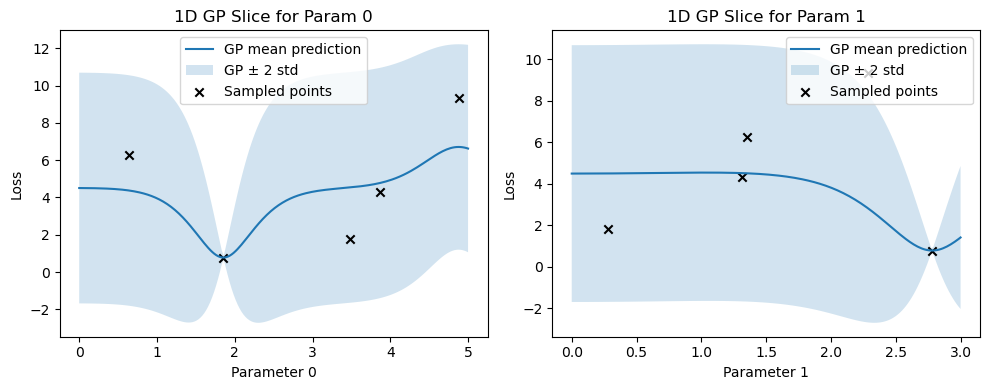

Iteration 1/20: new loss=7.3423, best so far=0.7771


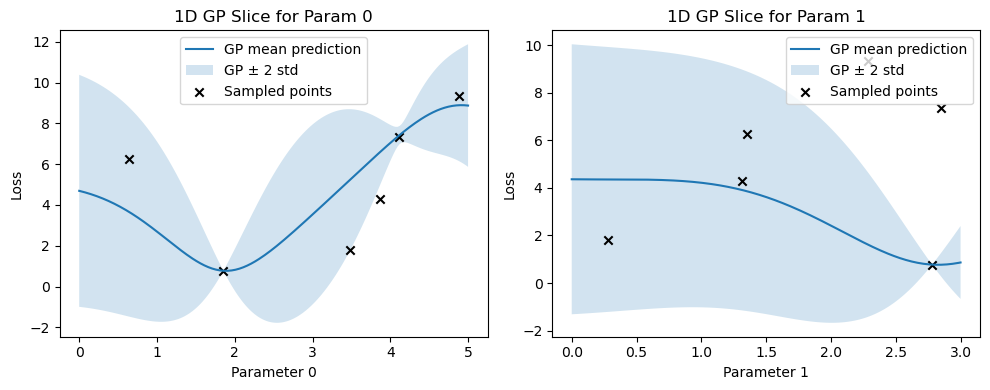

Iteration 2/20: new loss=0.9349, best so far=0.7771


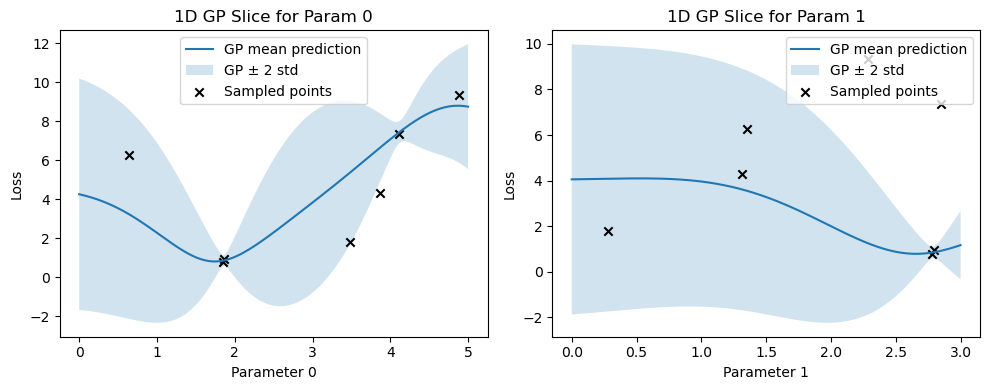

Iteration 3/20: new loss=0.6926, best so far=0.7771


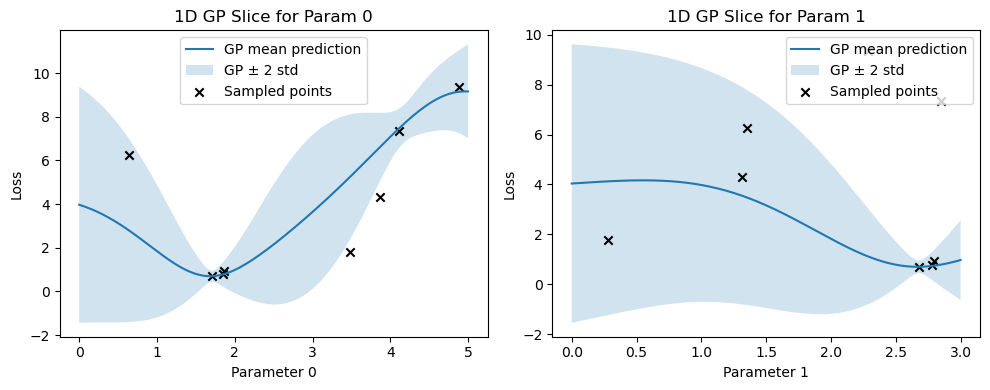

Iteration 4/20: new loss=11.2370, best so far=0.6926


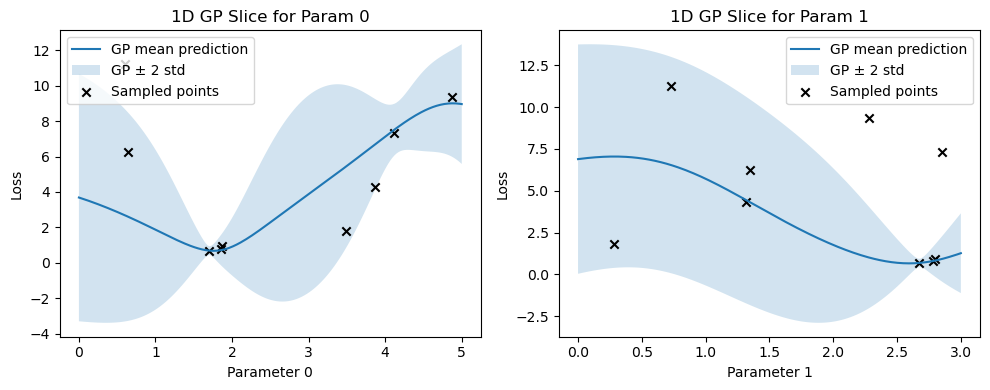

Iteration 5/20: new loss=0.5708, best so far=0.6926


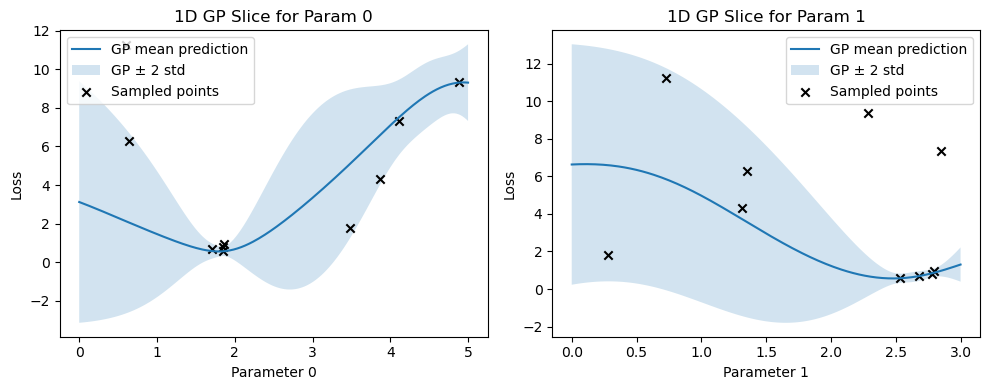

Iteration 6/20: new loss=0.6177, best so far=0.5708


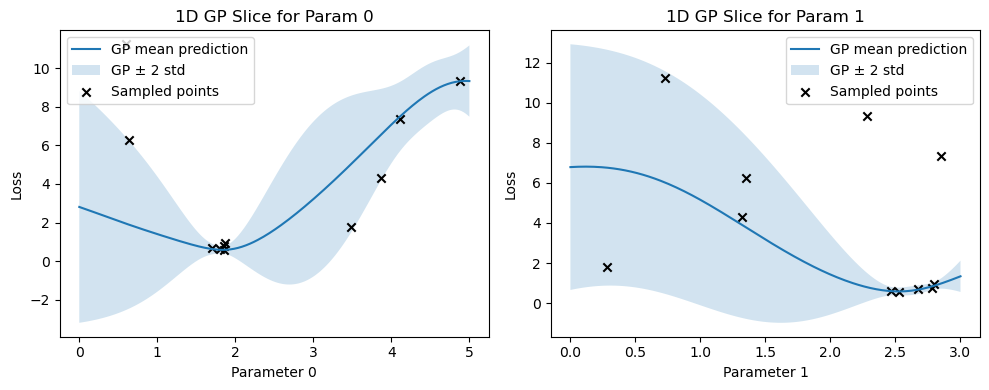

Iteration 7/20: new loss=10.4348, best so far=0.5708


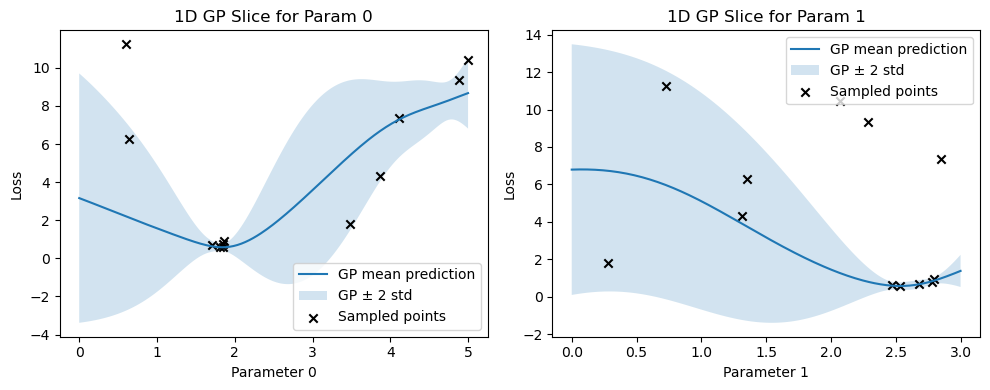

Iteration 8/20: new loss=0.1321, best so far=0.5708


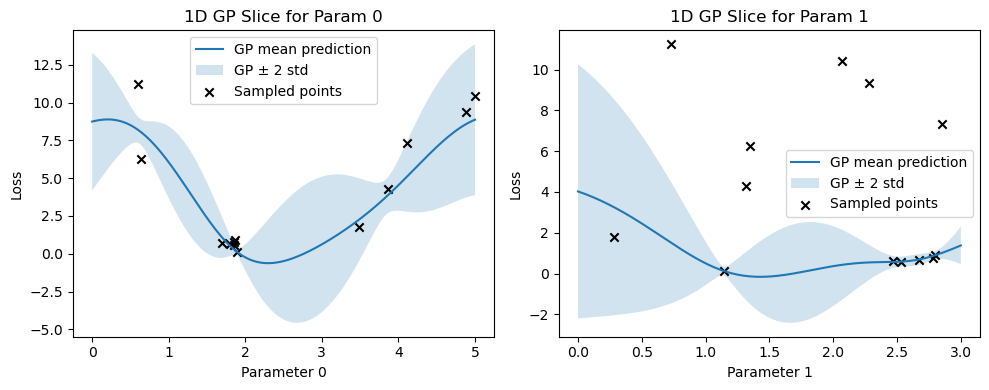

Iteration 9/20: new loss=0.3951, best so far=0.1321


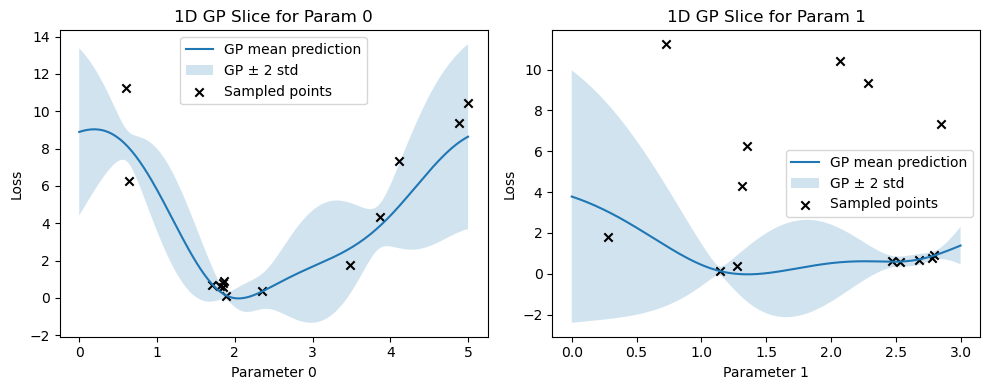

Iteration 10/20: new loss=0.1906, best so far=0.1321


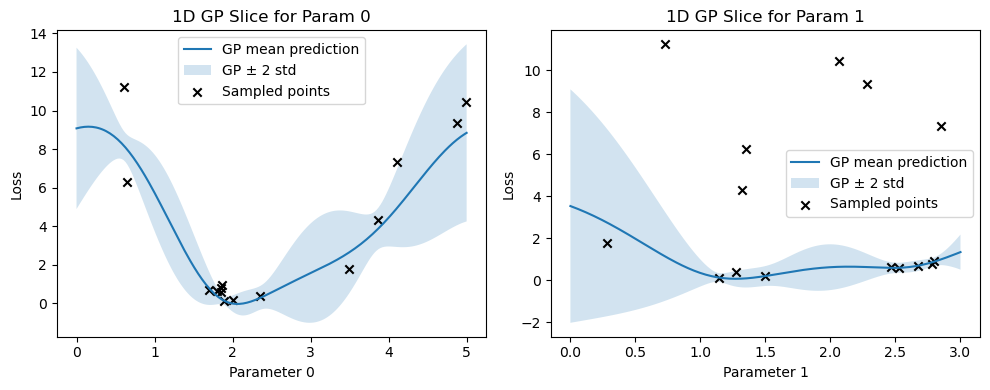

Iteration 11/20: new loss=0.1498, best so far=0.1321


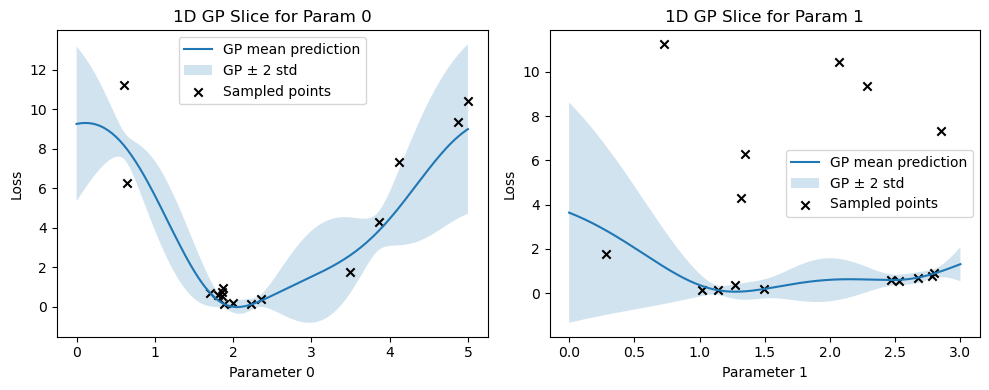

Iteration 12/20: new loss=0.0980, best so far=0.1321


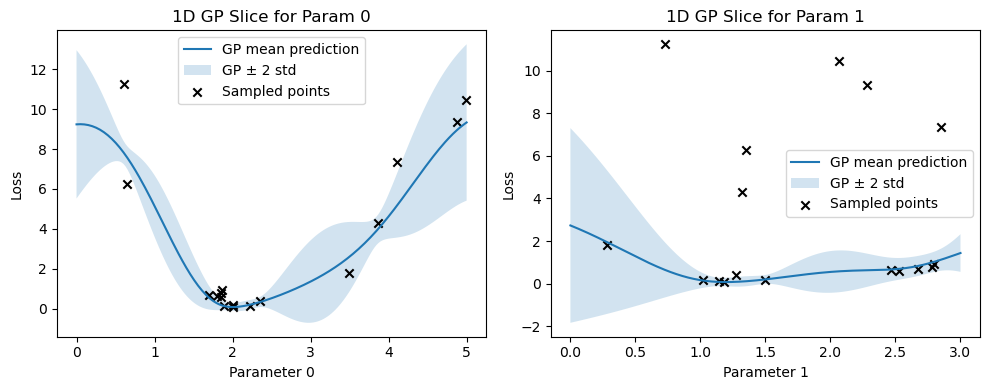

Iteration 13/20: new loss=0.0997, best so far=0.0980


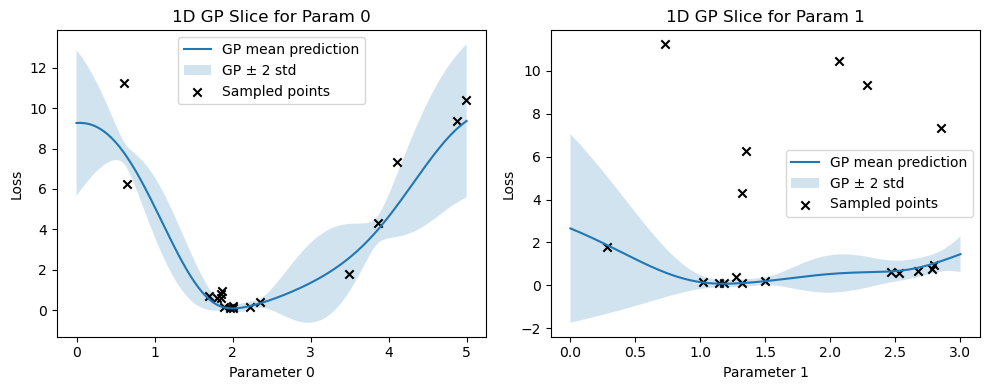

Iteration 14/20: new loss=0.0917, best so far=0.0980


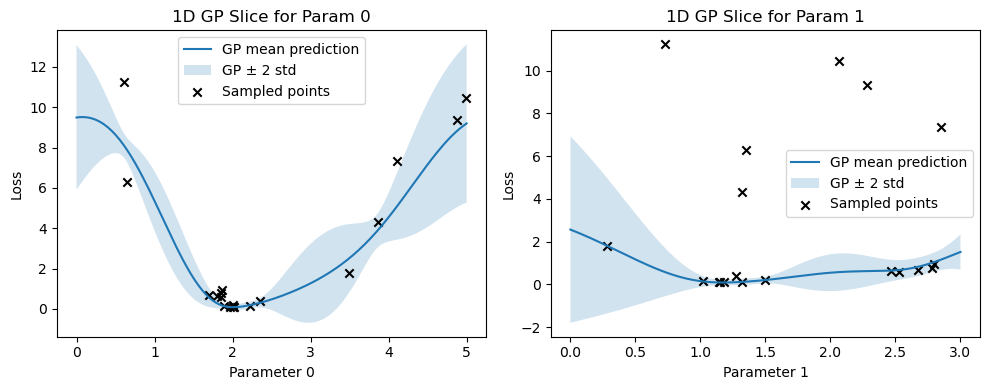

Iteration 15/20: new loss=5.9988, best so far=0.0917


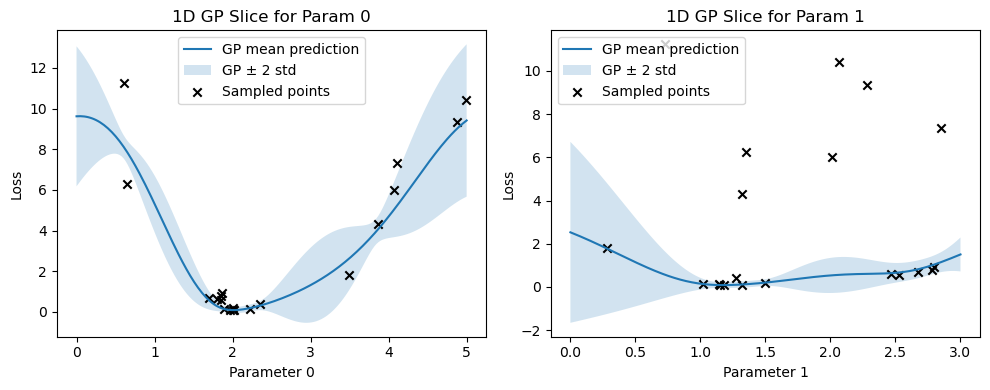

Iteration 16/20: new loss=0.1091, best so far=0.0917


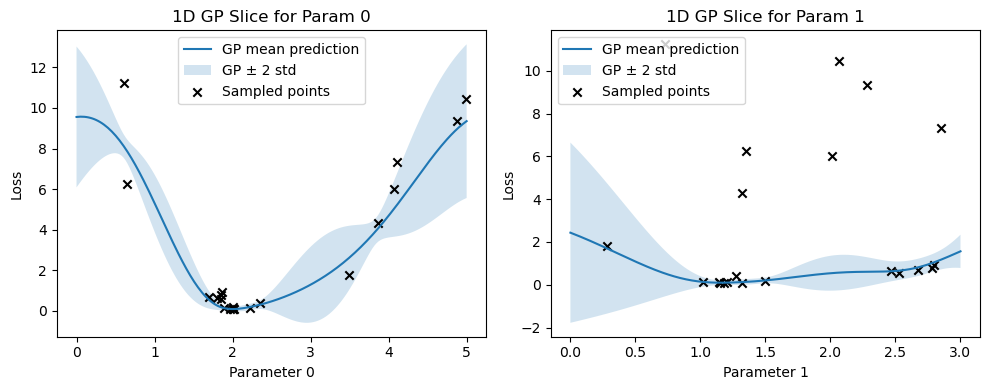

Iteration 17/20: new loss=0.0791, best so far=0.0917


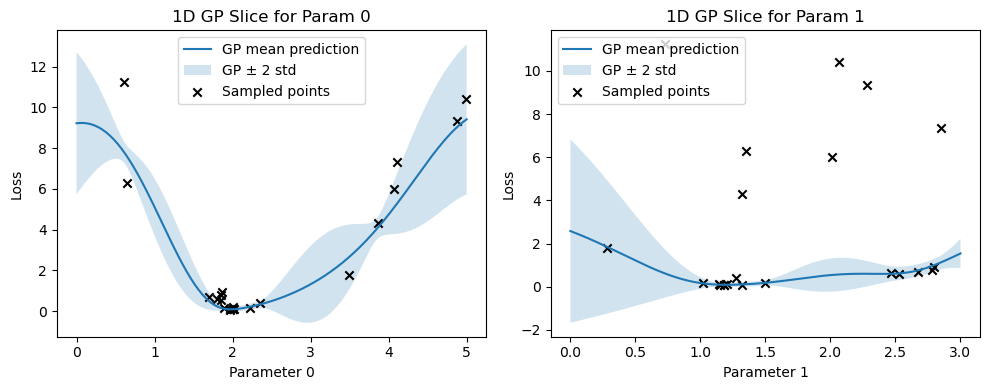

Iteration 18/20: new loss=5.3936, best so far=0.0791


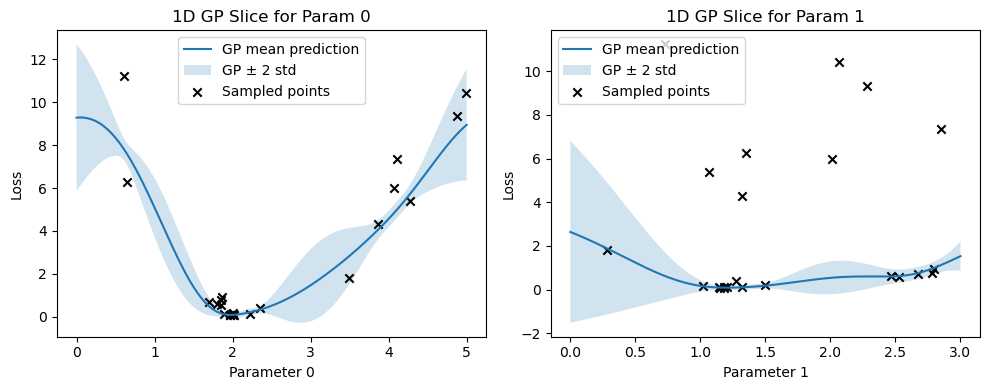

Iteration 19/20: new loss=0.2364, best so far=0.0791


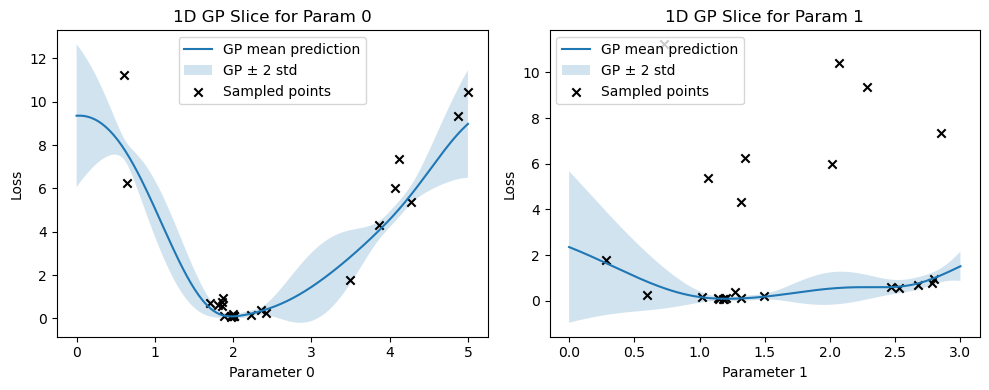

Iteration 20/20: new loss=2.6375, best so far=0.0791

Final:
  best_params=[1.97323307 1.18235432]
  best_loss=0.079059


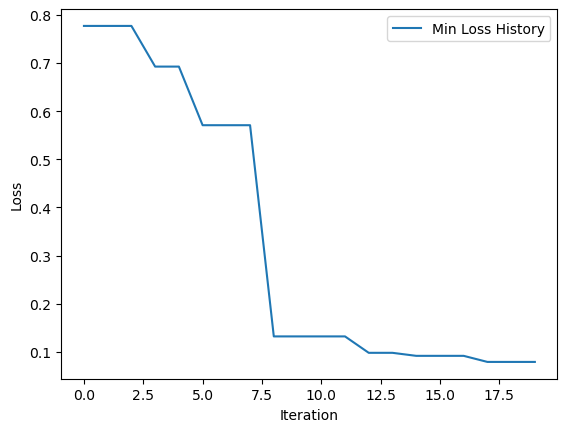

$alpha_T$ = 2.0
$alpha_E$ = 1.973233071107101
$beta_T$ = 1.0
$beta_E$ = 1.1823543240483874


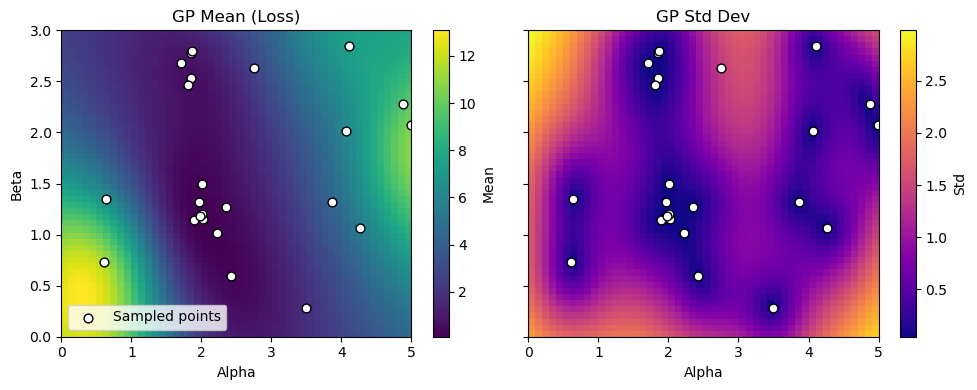

In [12]:
best_params, best_loss, history, gp_obj, Xs, Ys = simple_bayesopt_demo(
    x_values,                  # our set of conditions
    ground_truth_data,         # our observed data for each condition
    n_init=5,                  # the number of initial parameter sets to sample
    max_iter=20,               # the maximum number of iterations to compute
    param_bounds=param_bounds, # bounds for the parameter search
    sigma_model=0.4,           # we'll fix the st. dev. of the model to the true variability of the data for simplicity
    n_inst=5,                  # since the model is stochastic, the number of random samples to draw from each model
    random_state=42            # random state of rng for reproducibility
)

plt.figure()
plt.plot(history, label='Min Loss History')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(f"$alpha_T$ = {alpha_true}")
print(f"$alpha_E$ = {best_params[0]}")
print(f"$beta_T$ = {beta_true}")
print(f"$beta_E$ = {best_params[1]}")

fig, mean_ax, std_ax = plot_gp_heatmaps_2d_with_samples(
gp_obj,
param_bounds,
Xs,
Ys,
n_points=50
)

fig.savefig(os.path.join(mainDir,"plots","demo_GPcost_heatmap.png"))

Above you can see that the posterior changes with each iteration. As we continue to sample, we converge toward a single mininum in the loss. This value happens to be very close to the true minimum we are searching for. You can see the GP estimate of the loss in 2D parameter space at the end of the process.

How does this compare to the ground truth loss landscape? Let's run a parameter sweep to find out.

In [13]:
from itertools import product

# Search grid
alpha_list = np.linspace(param_bounds[0][0], param_bounds[0][1], 64)
beta_list = np.linspace(param_bounds[1][0], param_bounds[1][1], 64)

gt_loss_avg = np.zeros((len(alpha_list),len(beta_list)))
gt_loss_std = np.zeros((len(alpha_list),len(beta_list)))
Nsamp = 5 #number of losses to sample
seed = 123 #random seed

for (a_i, alpha), (b_i, beta) in tqdm(
    product(enumerate(alpha_list), enumerate(beta_list)),
    total=len(alpha_list)*len(beta_list),
    desc="Grid Search"):
    rng = np.random.default_rng(seed) #set random seed
    theta = [alpha,beta] #set theta

    # iterate through samples to estimate average and std of loss
    cost_vals = []
    for s_i in range(Nsamp):
        cost_val = evaluate_parameters_debug(
            theta,
            x_values,
            ground_truth_data,
            sigma_model=0.4,
            n_inst=5,
            seed=rng.integers(0,10_000)
        )
        cost_vals.append(cost_val)

    #save loss
    gt_loss_avg[a_i,b_i] = np.mean(cost_vals)
    gt_loss_std[a_i,b_i] = np.std(cost_vals)

Grid Search:   0%|          | 0/4096 [00:00<?, ?it/s]

Grid Search: 100%|██████████| 4096/4096 [00:38<00:00, 105.45it/s]


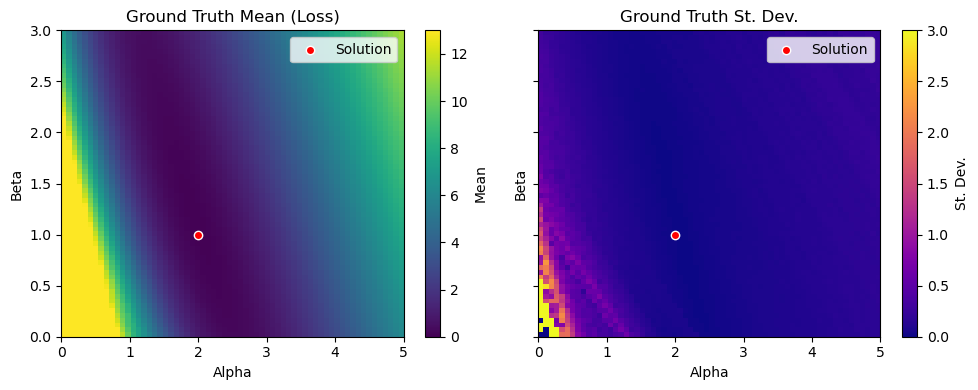

In [14]:
# Plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True)

# Left: mean
mean_ax = axes[0]
c0 = mean_ax.imshow(
    gt_loss_avg.T, 
    origin='lower', 
    extent=[param_bounds[0][0], param_bounds[0][1], param_bounds[1][0], param_bounds[1][1]],
    aspect='auto', 
    cmap='viridis',
    vmin=0,
    vmax=13
)
mean_ax.set_title("Ground Truth Mean (Loss)")
mean_ax.set_xlabel("Alpha")
mean_ax.set_ylabel("Beta")
fig.colorbar(c0, ax=mean_ax, label="Mean")

mean_ax.scatter(alpha_true, beta_true, c=['red'], edgecolor='white', label = "Solution")
mean_ax.legend()

# Right: st dev.
std_ax = axes[1]
c0 = std_ax.imshow(
    gt_loss_std.T, 
    origin='lower', 
    extent=[param_bounds[0][0], param_bounds[0][1], param_bounds[1][0], param_bounds[1][1]],
    aspect='auto', 
    cmap='plasma',
    vmin=0,
    vmax=3
)
std_ax.set_title("Ground Truth St. Dev.")
std_ax.set_xlabel("Alpha")
std_ax.set_ylabel("Beta")
fig.colorbar(c0, ax=std_ax, label="St. Dev.")

std_ax.scatter(alpha_true, beta_true, c=['red'], edgecolor='white', label = "Solution")
std_ax.legend()

plt.tight_layout()

fig.savefig(os.path.join(mainDir,"plots","demo_GTcost_heatmap.png"))

Now we've just gone through and calculated the cost at every point in a grid of paramters. This took longer, because it is more computationally costly. If you comapre the GP-estimated cost to the ground-truth cost, hopefully you'll see that the estmate wasn't too far off, especially close to the true minimum where most of the samples converged.

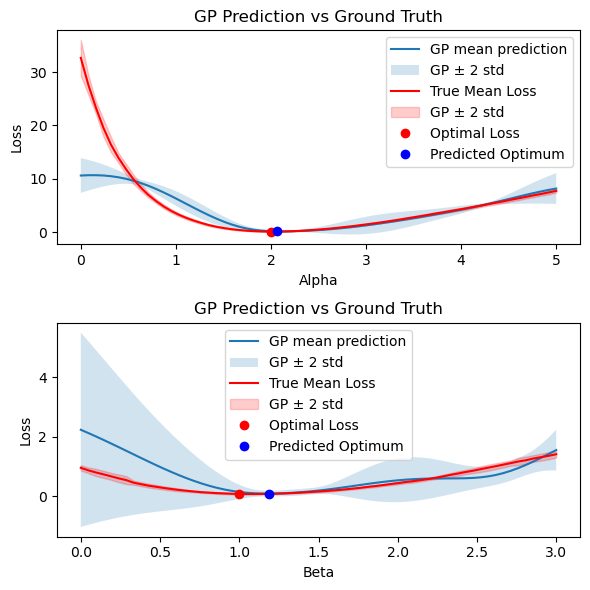

In [15]:
# Check out cross section at solution

fig, ax = plt.subplots(2,1,figsize=(6,6))

# Plot over alpha
predict_vals_alpha = np.array([alpha_list, np.repeat(beta_true,len(alpha_list))]).T
gp_predict_mean_alpha, gp_predict_std_alpha = gp_obj.predict(predict_vals_alpha, return_std=True)
ax[0].plot(alpha_list, gp_predict_mean_alpha, label='GP mean prediction')
ax[0].fill_between(
    alpha_list,
    gp_predict_mean_alpha - 2.0 * gp_predict_std_alpha,
    gp_predict_mean_alpha + 2.0 * gp_predict_std_alpha,
    alpha=0.2,
    label='GP ± 2 std'
)
beta_true_i = np.argmin(np.abs(beta_list - beta_true))
true_mean_alpha = np.squeeze(gt_loss_avg[:,beta_true_i])
true_std_alpha = np.squeeze(gt_loss_std[:,beta_true_i])
ax[0].plot(alpha_list, true_mean_alpha, '-r', label="True Mean Loss")
ax[0].fill_between(
    alpha_list,
    true_mean_alpha - 2.0 * true_std_alpha,
    true_mean_alpha + 2.0 * true_std_alpha,
    alpha=0.2,
    label='GP ± 2 std',
    color='red'
)
ax[0].plot(alpha_true, np.min(true_mean_alpha), 'or', label="Optimal Loss")
ax[0].plot(alpha_list[np.argmin(gp_predict_mean_alpha)],np.min(gp_predict_mean_alpha), 'ob', label="Predicted Optimum")

ax[0].set_title("GP Prediction vs Ground Truth")
ax[0].set_xlabel("Alpha")
ax[0].set_ylabel("Loss")
ax[0].legend()

# Plot over beta
predict_vals_beta = np.array([np.repeat(alpha_true,len(beta_list)), beta_list]).T
gp_predict_mean_beta, gp_predict_std_beta = gp_obj.predict(predict_vals_beta, return_std=True)
ax[1].plot(beta_list, gp_predict_mean_beta, label='GP mean prediction')
ax[1].fill_between(
    beta_list,
    gp_predict_mean_beta - 2.0 * gp_predict_std_beta,
    gp_predict_mean_beta + 2.0 * gp_predict_std_beta,
    alpha=0.2,
    label='GP ± 2 std'
)
alpha_true_i = np.argmin(np.abs(alpha_list - alpha_true))
true_mean_beta = np.squeeze(gt_loss_avg[alpha_true_i,:])
true_std_beta = np.squeeze(gt_loss_std[alpha_true_i,:])
ax[1].plot(beta_list, true_mean_beta, '-r', label="True Mean Loss")
ax[1].fill_between(
    beta_list,
    true_mean_beta - 2.0 * true_std_beta,
    true_mean_beta + 2.0 * true_std_beta,
    alpha=0.2,
    label='GP ± 2 std',
    color='red'
)

ax[1].plot(beta_true, np.min(true_mean_beta), 'or', label="Optimal Loss")
ax[1].plot(beta_list[np.argmin(gp_predict_mean_beta)],np.min(gp_predict_mean_beta), 'ob', label="Predicted Optimum")

ax[1].set_title("GP Prediction vs Ground Truth")
ax[1].set_xlabel("Beta")
ax[1].set_ylabel("Loss")
ax[1].legend()

plt.tight_layout()

fig.savefig(os.path.join(mainDir,"plots","demo_GPvGT_loss.png"))

When we check out the cross section of the GP-estimate and the true loss, we can see this even more clearly. The estimate has lower undertainty near positions where we have lots of samples. It also more closely approximates the true cost in those regions. You can see that we get pretty close to the optimal paramters using the Bayesian Optimization approach, which used orders-of-magnitude fewer samples.

Now let's see how the optimized model fits the data.

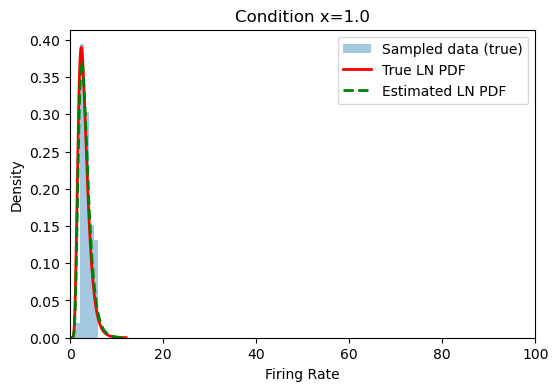

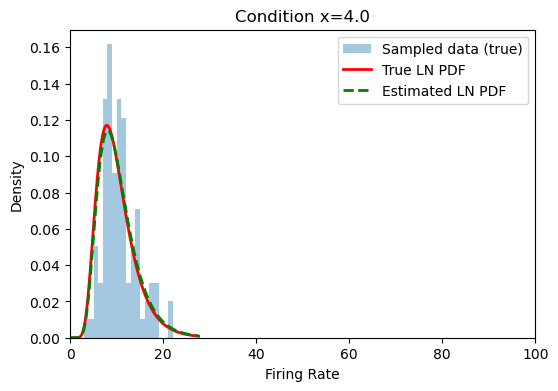

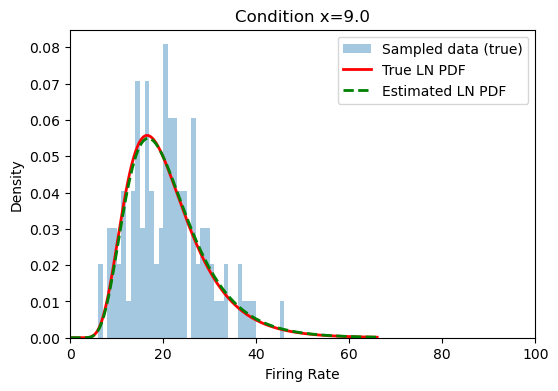

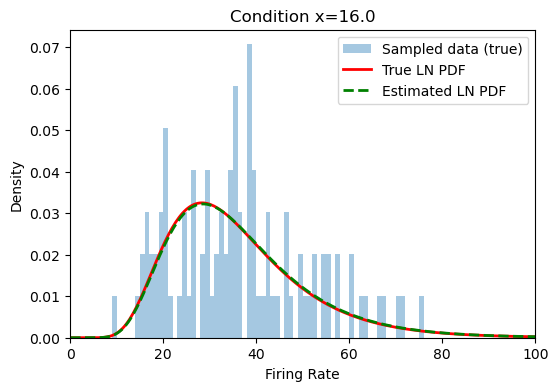

In [16]:
# Compare learned solution to true distribution

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

def plot_true_vs_estimated_distribution(
    ground_truth_samples,
    x_condition,
    alpha_true, beta_true, sigma_true,
    alpha_est, beta_est, sigma_est, bin_size=5,
    xlims=None
):
    """
    Plot a histogram of the ground_truth_samples for one condition,
    then overlay:
      - The theoretical PDF for the true lognormal distribution
        with (alpha_true, beta_true, sigma_true).
      - The theoretical PDF for the estimated lognormal distribution
        with (alpha_est, beta_est, sigma_est).

    Parameters
    ----------
    ground_truth_samples : np.ndarray
        1D array of integer firing rates for the chosen condition, e.g. ground_truth_data[i].
    x_condition : float
        The x-value for this condition (since your distribution depends on alpha*x + beta*sqrt(x)).
    alpha_true, beta_true, sigma_true : float
        The known true distribution parameters used for ground-truth.
    alpha_est, beta_est, sigma_est : float
        The estimated distribution parameters from Bayesian optimization.
    """

    # 1. Build a histogram from the ground_truth_samples
    fig, ax = plt.subplots(figsize=(6,4))
    ax.hist(ground_truth_samples, bins=np.arange(0,np.max(ground_truth_samples),bin_size), density=True, alpha=0.4, label='Sampled data (true)')

    # For convenience, define a function that returns the PDF from (alpha, beta, sigma).
    def lognormal_pdf(alpha, beta, sigma, x_cond, x_range):
        mean_real = alpha*x_cond + beta*np.sqrt(x_cond)
        if mean_real <= 0:
            mean_real = 1e-9  # clamp to positive
        mu = np.log(mean_real) - 0.5*(sigma**2)
        # shape parameter = sigma, scale = exp(mu)
        return lognorm.pdf(x_range, s=sigma, scale=np.exp(mu))

    # 2. Prepare a range of firing rates over which to plot the PDF curves
    max_rate = max(ground_truth_samples.max(), 10)  # or pick something larger
    x_plot = np.linspace(0, max_rate*1.2, 300)

    # 3. Plot the “true” lognormal PDF
    pdf_true = lognormal_pdf(alpha_true, beta_true, sigma_true, x_condition, x_plot)
    ax.plot(x_plot, pdf_true, 'r-', lw=2, label='True LN PDF')

    # 4. Plot the “estimated” lognormal PDF
    pdf_est = lognormal_pdf(alpha_est, beta_est, sigma_est, x_condition, x_plot)
    ax.plot(x_plot, pdf_est, 'g--', lw=2, label='Estimated LN PDF')

    # 5. Final labeling
    ax.set_xlabel('Firing Rate')
    ax.set_xlim(xlims)
    ax.set_ylabel('Density')
    ax.set_title(f'Condition x={x_condition}')
    ax.legend()
    plt.show()
    
    return fig, ax

Ncond = len(x_values)
for i in range(Ncond):
    fig, ax = plot_true_vs_estimated_distribution(
        ground_truth_samples=ground_truth_data[i],
        x_condition=x_values[i],
        alpha_true=alpha_true,
        beta_true=beta_true,
        sigma_true=sigma_gt,
        alpha_est=best_params[0],
        beta_est=best_params[1],
        sigma_est=sigma_gt,
        bin_size=1,
        xlims=[0,100]
    )
    
    fig.savefig(os.path.join(mainDir,"plots",f"demo_overlayGPfit_x={x_values[i]}.png"))

The estimated probability distribution over firing rates (green) closely matches the true probability distribution over firing rates for each condition (red).